# TMDB 5000 Movies — Exploratory Data Analysis

This notebook performs an end-to-end exploratory data analysis on the TMDB 5000 Movies dataset.  
The goal is to understand the structure of the data, handle quality issues, engineer features from nested columns, and explore key relationships that affect movie revenue and ratings.

**Analysis questions:**
- What is the genre distribution across all movies?
- Is there a relationship between budget and revenue?
- Does a higher rating correlate with higher revenue?
- Which months generate the highest total revenue?
- What are the top 10 highest-grossing movies?
- How does runtime relate to revenue and ratings?

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os

pd.set_option('display.max_columns', None)

# All generated plots are saved here for use in the README
os.makedirs('graphs', exist_ok=True)

## 2. Load Data

In [2]:
df = pd.read_csv('tmdb_5000_movies.csv')
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

## 3. Data Cleaning

### 3.1 Drop Irrelevant Columns

The following columns are dropped because they carry no analytical value for this EDA:  
- `homepage`, `id`, `status` — metadata with no signal for revenue or ratings  
- `overview`, `tagline`, `title` — free-text fields that would require NLP to be useful

In [4]:
df.drop(columns=['homepage', 'id', 'overview', 'tagline', 'title', 'status'], inplace=True)

### 3.2 Inspect Missing Values

In [5]:
# Identify rows with missing release_date — only 1 row, safe to drop
df[df['release_date'].isnull()]

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,vote_average,vote_count
4553,0,[],[],en,America Is Still the Place,0.0,[],[],NaN,0,0.0,[],0.0,0


In [6]:
# Identify rows with missing runtime
df[df['runtime'].isnull()]

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,vote_average,vote_count
2656,15000000,"[{""id"": 18, ""name"": ""Drama""}]","[{""id"": 717, ""name"": ""pope""}, {""id"": 5565, ""na...",it,Chiamatemi Francesco - Il Papa della gente,0.738646,"[{""name"": ""Taodue Film"", ""id"": 45724}]","[{""iso_3166_1"": ""IT"", ""name"": ""Italy""}]",2015-12-03,0,NaN,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",7.3,12
4140,2,"[{""id"": 99, ""name"": ""Documentary""}]","[{""id"": 6027, ""name"": ""music""}, {""id"": 225822,...",en,"To Be Frank, Sinatra at 100",0.050625,"[{""name"": ""Eyeline Entertainment"", ""id"": 60343}]","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}]",2015-12-12,0,NaN,[],0.0,0


### 3.3 Handle Missing Values

- The row at index 4553 has a missing `release_date` and cannot be used for time-based analysis — it is dropped.  
- The 2 rows with missing `runtime` are filled with the **median** rather than the mean, because runtime may have outliers that would skew the mean.

In [7]:
df = df.drop(index=4553)
df['runtime'] = df['runtime'].fillna(df['runtime'].median())

### 3.4 Parse JSON-like String Columns

Several columns are stored as stringified JSON lists of objects (e.g., `[{"id": 28, "name": "Action"}, ...]`).  
We parse them with `ast.literal_eval` and extract only the `name` field, since the numeric IDs add no analytical value.

In [8]:
def extract_names(df, columns):
    for col in columns:
        df[col] = df[col].apply(ast.literal_eval)
        df[col] = df[col].apply(lambda x: [i['name'] for i in x])
    return df

columns = ['genres', 'keywords', 'spoken_languages', 'production_companies', 'production_countries']
df = extract_names(df, columns)
df.head()

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,vote_average,vote_count
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...",en,Avatar,150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,"[English, Español]",7.2,11800
1,300000000,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...",en,Pirates of the Caribbean: At World's End,139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",[United States of America],2007-05-19,961000000,169.0,[English],6.9,4500
2,245000000,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...",en,Spectre,107.376788,"[Columbia Pictures, Danjaq, B24]","[United Kingdom, United States of America]",2015-10-26,880674609,148.0,"[Français, English, Español, Italiano, Deutsch]",6.3,4466
3,250000000,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...",en,The Dark Knight Rises,112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",[United States of America],2012-07-16,1084939099,165.0,[English],7.6,9106
4,260000000,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...",en,John Carter,43.926995,[Walt Disney Pictures],[United States of America],2012-03-07,284139100,132.0,[English],6.1,2124


## 4. Feature Engineering

### 4.1 One-Hot Encoding for Multi-Valued Columns

Each of the list columns can have multiple values per movie (a movie can belong to several genres, be produced in multiple countries, etc.).  
We use `explode` + `get_dummies` + `groupby` to create binary indicator columns for each unique value.

To avoid a very sparse and wide feature space, we cap `production_companies` at the top 20 and `keywords` at the top 50 by frequency.

In [9]:
top_n_config = {
    'genres': None,
    'spoken_languages': None,
    'production_countries': None,
    'production_companies': 20,
    'keywords': 50
}

def get_dummies_for_columns(df, top_n_config):
    result = {}
    for col, top_n in top_n_config.items():
        exploded = df[col].explode()
        if top_n:
            top_values = exploded.value_counts().nlargest(top_n).index
            exploded = exploded[exploded.isin(top_values)]
        dummies = pd.get_dummies(exploded)
        result[col] = dummies.groupby(level=0).max().reindex(df.index, fill_value=0)
    return result

dummies = get_dummies_for_columns(df, top_n_config)

for col, dummy_df in dummies.items():
    df = df.join(dummy_df, rsuffix=f'_{col}')

df.head()

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,vote_average,vote_count,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,,??????,Afrikaans,Bahasa indonesia,Bamanankan,Bosanski,Català,Cymraeg,Dansk,Deutsch,Eesti,English,Español,Esperanto,Français,Gaeilge,Galego,Hrvatski,Italiano,Kiswahili,Latin,Magyar,Nederlands,No Language,Norsk,Polski,Português,Pусский,Română,Slovenčina,Slovenščina,Somali,Srpski,Tiếng Việt,Türkçe,Wolof,isiZulu,shqip,suomi,svenska,Íslenska,Český,ελληνικά,Український,български език,қазақ,עִבְרִית,اردو,العربية,فارسی,پښتو,हिन्दी,বাংলা,ਪੰਜਾਬੀ,தமிழ்,తెలుగు,ภาษาไทย,ქართული,广州话 / 廣州話,日本語,普通话,한국어/조선말,Afghanistan,Algeria,Angola,Argentina,Aruba,Australia,Austria,Bahamas,Belgium,Bhutan,Bolivia,Bosnia and Herzegovina,Brazil,Bulgaria,Cambodia,Cameroon,Canada,Chile,China,Colombia,Cyprus,Czech Republic,Denmark,Dominica,Dominican Republic,Ecuador,Egypt,Fiji,Finland,France,Germany,Greece,Guadaloupe,Guyana,Hong Kong,Hungary,Iceland,India,Indonesia,Iran,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,Kyrgyz Republic,Lebanon,Libyan Arab Jamahiriya,Lithuania,Luxembourg,Malaysia,Malta,Mexico,Monaco,Morocco,Netherlands,New Zealand,Nigeria,Norway,Pakistan,Panama,Peru,Philippines,Poland,Portugal,Romania,Russia,Serbia,Serbia and Montenegro,Singapore,Slovakia,Slovenia,South Africa,South Korea,Spain,Sweden,Switzerland,Taiwan,Thailand,Tunisia,Turkey,Ukraine,United Arab Emirates,United Kingdom,United States of America,Canal+,Columbia Pictures,Columbia Pictures Corporation,DreamWorks SKG,Dune Entertainment,Fox Searchlight Pictures,Lionsgate,Metro-Goldwyn-Mayer (MGM),Miramax Films,New Line Cinema,Paramount Pictures,Regency Enterprises,Relativity Media,Touchstone Pictures,Twentieth Century Fox Film Corporation,United Artists,Universal Pictures,Village Roadshow Pictures,Walt Disney Pictures,Warner Bros.,3d,aftercreditsstinger,airplane,alien,based on comic book,based on novel,based on true story,biography,corruption,daughter,drug,duringcreditsstinger,dying and death,dystopia,escape,family,father son relationship,friends,friendship,high school,hospital,independent film,kidnapping,london england,los angeles,love,magic,martial arts,murder,musical,new york,nudity,party,police,prison,remake,revenge,sequel,serial killer,sex,sport,suicide,superhero,suspense,teenager,time travel,violence,wedding,woman director,world war ii
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...",en,Avatar,150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,"[English, Español]",7.2,11800,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,Fal

### 4.2 Remove Malformed Language Columns

After encoding, two columns appear with empty or corrupted names — these are artifacts of malformed entries in the original data and carry no information.

In [10]:
df.drop(columns=['', '??????'], inplace=True)

### 4.3 Extract Date Features

We extract `year` and `month` from `release_date` to enable time-based aggregations.  
`release_date` is converted to datetime first to ensure correct parsing.

In [11]:
df['release_date'] = pd.to_datetime(df['release_date'])
df['year'] = df['release_date'].dt.year
df['month'] = df['release_date'].dt.month

df.head()

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,vote_average,vote_count,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,Afrikaans,Bahasa indonesia,Bamanankan,Bosanski,Català,Cymraeg,Dansk,Deutsch,Eesti,English,Español,Esperanto,Français,Gaeilge,Galego,Hrvatski,Italiano,Kiswahili,Latin,Magyar,Nederlands,No Language,Norsk,Polski,Português,Pусский,Română,Slovenčina,Slovenščina,Somali,Srpski,Tiếng Việt,Türkçe,Wolof,isiZulu,shqip,suomi,svenska,Íslenska,Český,ελληνικά,Український,български език,қазақ,עִבְרִית,اردو,العربية,فارسی,پښتو,हिन्दी,বাংলা,ਪੰਜਾਬੀ,தமிழ்,తెలుగు,ภาษาไทย,ქართული,广州话 / 廣州話,日本語,普通话,한국어/조선말,Afghanistan,Algeria,Angola,Argentina,Aruba,Australia,Austria,Bahamas,Belgium,Bhutan,Bolivia,Bosnia and Herzegovina,Brazil,Bulgaria,Cambodia,Cameroon,Canada,Chile,China,Colombia,Cyprus,Czech Republic,Denmark,Dominica,Dominican Republic,Ecuador,Egypt,Fiji,Finland,France,Germany,Greece,Guadaloupe,Guyana,Hong Kong,Hungary,Iceland,India,Indonesia,Iran,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,Kyrgyz Republic,Lebanon,Libyan Arab Jamahiriya,Lithuania,Luxembourg,Malaysia,Malta,Mexico,Monaco,Morocco,Netherlands,New Zealand,Nigeria,Norway,Pakistan,Panama,Peru,Philippines,Poland,Portugal,Romania,Russia,Serbia,Serbia and Montenegro,Singapore,Slovakia,Slovenia,South Africa,South Korea,Spain,Sweden,Switzerland,Taiwan,Thailand,Tunisia,Turkey,Ukraine,United Arab Emirates,United Kingdom,United States of America,Canal+,Columbia Pictures,Columbia Pictures Corporation,DreamWorks SKG,Dune Entertainment,Fox Searchlight Pictures,Lionsgate,Metro-Goldwyn-Mayer (MGM),Miramax Films,New Line Cinema,Paramount Pictures,Regency Enterprises,Relativity Media,Touchstone Pictures,Twentieth Century Fox Film Corporation,United Artists,Universal Pictures,Village Roadshow Pictures,Walt Disney Pictures,Warner Bros.,3d,aftercreditsstinger,airplane,alien,based on comic book,based on novel,based on true story,biography,corruption,daughter,drug,duringcreditsstinger,dying and death,dystopia,escape,family,father son relationship,friends,friendship,high school,hospital,independent film,kidnapping,london england,los angeles,love,magic,martial arts,murder,musical,new york,nudity,party,police,prison,remake,revenge,sequel,serial killer,sex,sport,suicide,superhero,suspense,teenager,time travel,violence,wedding,woman director,world war ii,year,month
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...",en,Avatar,150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,"[English, Español]",7.2,11800,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,

### 4.4 Final Shape Check

In [12]:
print(f'Shape: {df.shape}')
print(f'Remaining nulls:\n{df.isna().sum()[df.isna().sum() > 0]}')

Shape: (4802, 254)
Remaining nulls:
Series([], dtype: int64)


## 5. Exploratory Analysis

### 5.1 Genre Distribution

We count the total number of movies per genre to understand which genres dominate the dataset.  
A pie chart is used here because we are interested in relative proportions across a small, fixed set of categories.

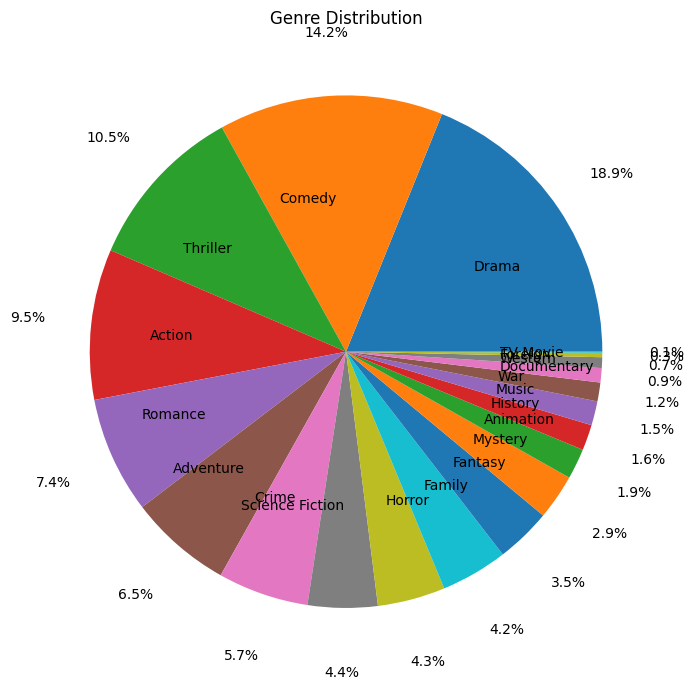

In [13]:
genre_counts = dummies['genres'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%',
       pctdistance=1.25, labeldistance=0.6)
ax.set_title('Genre Distribution')

plt.tight_layout()
plt.savefig('graphs/genre_pie.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Budget vs Revenue

We examine whether production budget is a reliable predictor of box office revenue.  
The Pearson correlation is computed first to quantify the linear relationship, then a scatter plot is used to visually inspect the spread and identify outliers.

In [14]:
print(df[['budget', 'revenue']].corr())

           budget   revenue
budget   1.000000  0.730806
revenue  0.730806  1.000000


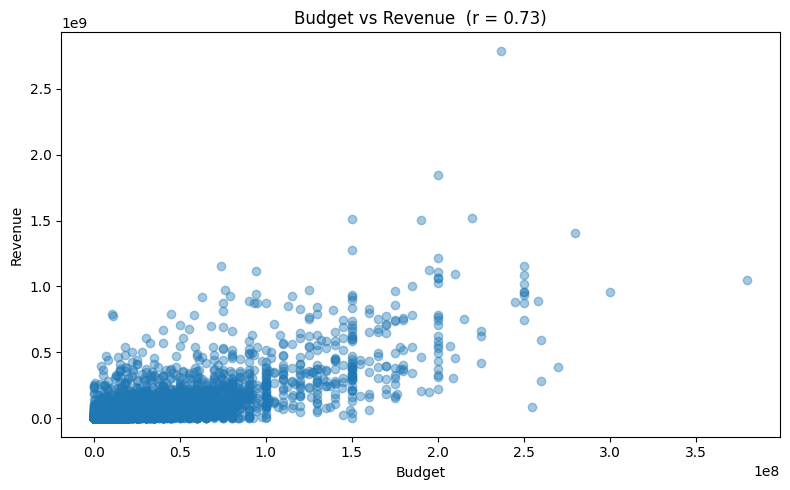

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['budget'], df['revenue'], alpha=0.4)
ax.set_xlabel('Budget')
ax.set_ylabel('Revenue')
ax.set_title('Budget vs Revenue  (r = 0.73)')

plt.tight_layout()
plt.savefig('graphs/budget_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Rating vs Revenue

We test whether audience ratings drive financial performance.  
A regression plot is used to show both the scatter and the fitted trend line, making it easier to judge the direction and strength of the relationship visually alongside the correlation coefficient.

In [16]:
print(df[['vote_average', 'revenue']].corr())

              vote_average   revenue
vote_average      1.000000  0.197153
revenue           0.197153  1.000000


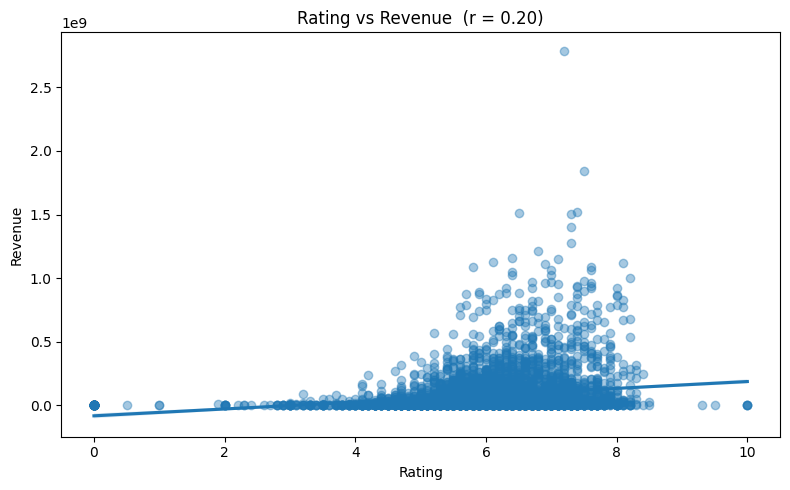

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(x='vote_average', y='revenue', data=df, ax=ax, scatter_kws={'alpha': 0.4})
ax.set_title('Rating vs Revenue  (r = 0.20)')
ax.set_xlabel('Rating')
ax.set_ylabel('Revenue')

plt.tight_layout()
plt.savefig('graphs/rating_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Revenue by Release Month

We aggregate total revenue per calendar month to detect seasonal patterns in movie performance.  
Total revenue (rather than average) is used here because it reflects the overall market volume per month, which is more relevant for understanding industry release strategy.

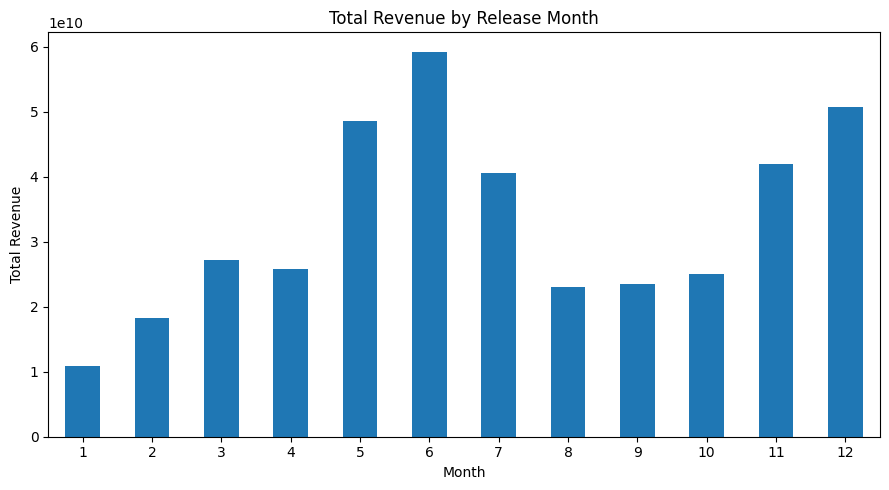

In [18]:
month_rev = df.groupby('month')['revenue'].sum()

fig, ax = plt.subplots(figsize=(9, 5))
month_rev.plot(kind='bar', ax=ax)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')
ax.set_title('Total Revenue by Release Month')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('graphs/revenue_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Top 10 Highest-Grossing Movies

We isolate the 10 movies with the highest total revenue to identify the dominant titles in the dataset.  
A horizontal bar chart is used for readability when comparing labeled categories.

In [19]:
top_rev = df[['original_title', 'revenue']].sort_values(by='revenue', ascending=False).head(10)
top_rev

,original_title,revenue
0,Avatar,2787965087
25,Titanic,1845034188
16,The Avengers,1519557910
28,Jurassic World,1513528810
44,Furious 7,1506249360
7,Avengers: Age of Ultron,1405403694
124,Frozen,1274219009
31,Iron Man 3,1215439994
546,Minions,1156730962
26,Captain America: Civil War,1153304495


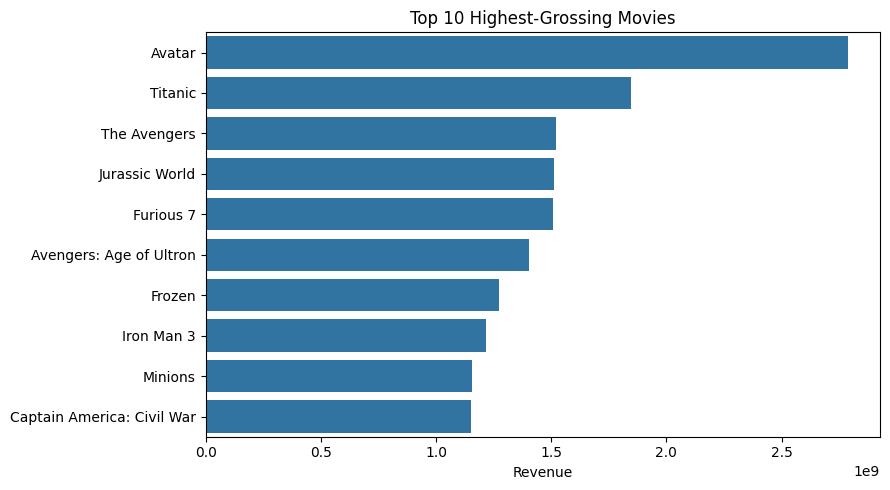

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x='revenue', y='original_title', data=top_rev, ax=ax)
ax.set_title('Top 10 Highest-Grossing Movies')
ax.set_xlabel('Revenue')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('graphs/top10_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Runtime vs Revenue

We check whether longer movies tend to earn more at the box office.  
This helps determine if runtime is a meaningful feature for revenue prediction or a noise variable.

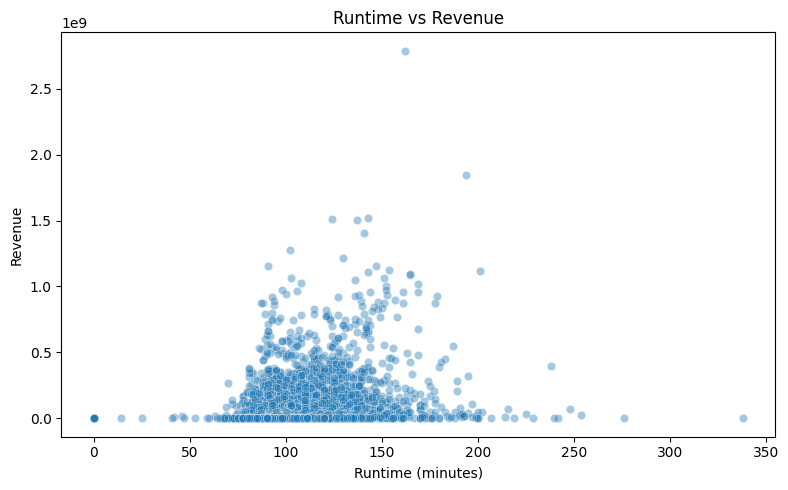

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='runtime', y='revenue', alpha=0.4, ax=ax)
ax.set_title('Runtime vs Revenue')
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('Revenue')

plt.tight_layout()
plt.savefig('graphs/runtime_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.7 Runtime vs Rating

We check whether movie length has any effect on how audiences rate a film.  
Very short or very long runtimes might correlate with lower ratings due to pacing issues.

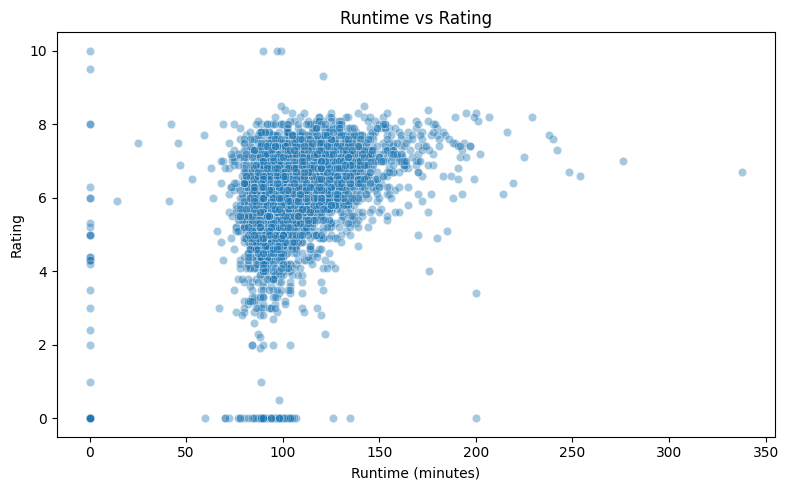

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='runtime', y='vote_average', alpha=0.4, ax=ax)
ax.set_title('Runtime vs Rating')
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('Rating')

plt.tight_layout()
plt.savefig('graphs/runtime_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Key Findings

- **Budget is the strongest predictor of revenue** (r = 0.73). Higher production budgets strongly correlate with higher box office returns, likely because large-budget films benefit from better marketing and wider distribution.
- **Rating has a weak effect on revenue** (r = 0.20). Critical or audience reception alone does not drive financial performance.
- **Summer (May–July) and November show the highest cumulative revenue**, consistent with the industry's blockbuster release calendar.
- **Drama is the most common genre** by count, but the top-grossing films are predominantly Action and Adventure.
- **Runtime shows no strong linear relationship** with either revenue or rating.